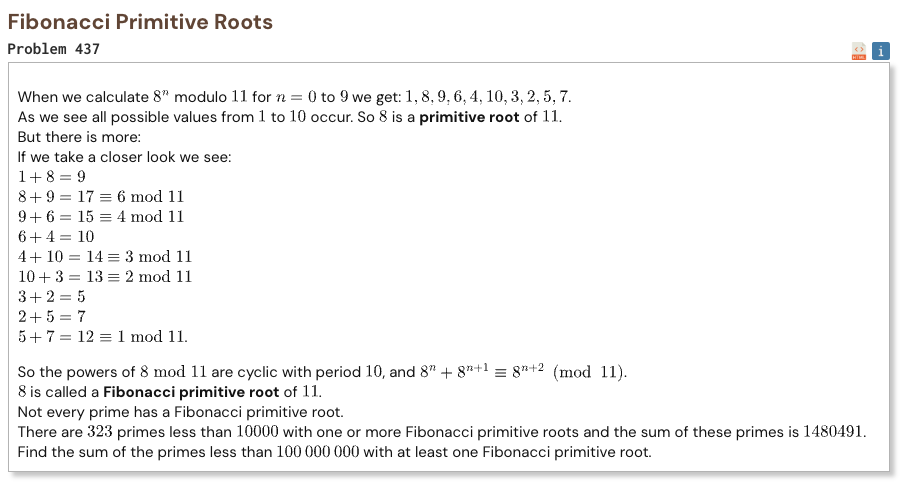

## Initial approach

-   build a sieve that stores the smallest prime factor for odd numbers
-   use the same sieve both to find primes and to factor each prime minus one quickly
-   only check primes that can have a square root of five
-   find the two possible Fibonacci roots with Tonelli Shanks
-   factor prime minus one using the precomputed sieve instead of sympy
-   test whether either candidate has the full possible order
-   add the prime when one of the candidates is a primitive root

In [1]:
%%time

from array import array
from math import isqrt

limit = 100_000_000

def build_spf(limit):
    size = limit // 2
    spf = array("H", [0]) * size
    root = isqrt(limit - 1)

    for p in range(3, root + 1, 2):
        if spf[p // 2] == 0:
            for n in range(p * p, limit, 2 * p):
                idx = n // 2
                if spf[idx] == 0:
                    spf[idx] = p

    return spf

def prime_factors(n, spf):
    factors = [2]

    while n % 2 == 0:
        n //= 2

    while n > 1:
        d = spf[n // 2]

        if d == 0:
            factors.append(n)
            break

        factors.append(d)

        while n % d == 0:
            n //= d

    return factors

def tonelli_shanks(n, p):
    if p % 4 == 3:
        return pow(n, (p + 1) // 4, p)

    q = p - 1
    s = 0

    while q % 2 == 0:
        s += 1
        q //= 2

    z = 2

    while pow(z, (p - 1) // 2, p) != p - 1:
        z += 1

    c = pow(z, q, p)
    x = pow(n, (q + 1) // 2, p)
    t = pow(n, q, p)
    m = s

    while t != 1:
        i = 1
        temp = (t * t) % p

        while temp != 1:
            temp = (temp * temp) % p
            i += 1

        b = pow(c, 1 << (m - i - 1), p)

        x = (x * b) % p
        t = (t * b * b) % p
        c = (b * b) % p
        m = i

    return x

spf = build_spf(limit)

result = 5

for p in range(7, limit, 2):
    if spf[p // 2] != 0:
        continue

    if p % 5 not in (1, 4):
        continue

    s = tonelli_shanks(5, p)
    inv2 = (p + 1) // 2

    roots = (
        ((1 + s) * inv2) % p,
        ((1 - s) * inv2) % p
    )

    factors = prime_factors(p - 1, spf)

    for g in roots:
        if all(
            pow(g, (p - 1) // q, p) != 1
            for q in factors
        ):
            result += p
            break

print("Result:", result)

Result: 74204709657207
CPU times: user 28.6 s, sys: 92.2 ms, total: 28.7 s
Wall time: 28.7 s
